In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Pastikan data iku masih relevan utk sekarang masih sampai 7 okt, lalu buat 8 okt dari sql dari api soko rpl nantie bisa ambil data okt 8 dari agregasi hari tersebut dan diambil mediannya

In [ ]:
df_final = pd.read_excel('/content/aqicn_Combin.xlsx')

In [ ]:
df_final

,PM10,PM25,CO,SO2,NO2,O3
0,25.98,17.32,0.20,21.83,5.94,56.50
1,38.65,28.40,0.57,21.63,8.32,58.10
2,34.24,24.33,0.51,19.09,8.88,59.03
3,34.92,24.62,0.38,19.59,8.73,58.48
4,35.44,24.89,0.30,20.78,10.62,64.09
...,...,...,...,...,...,...
596,42.97,34.74,0.07,23.48,3.79,1.47
597,42.61,34.13,0.07,16.71,3.24,1.85
598,42.75,34.26,0.07,17.55,3.10,3.01
599,43.27,34.67,0.07,17.25,3.06,3.81


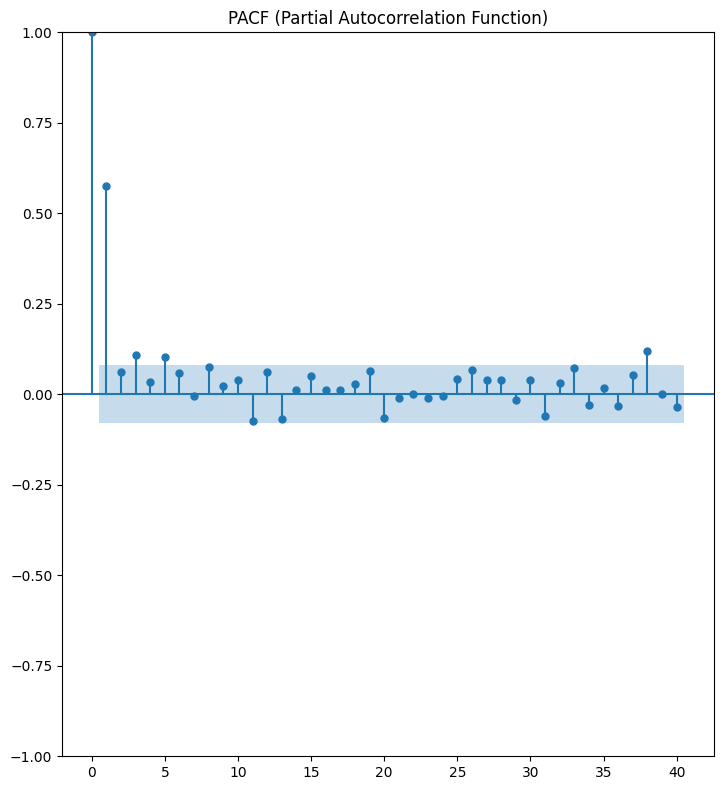

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

data_ts = df_final['PM25'].copy()
plt.figure(figsize=(14,8))

plt.subplot(1,2,2)
plot_pacf(data_ts, lags=40, method='ywm', ax=plt.gca())
plt.title("PACF (Partial Autocorrelation Function)")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from statsmodels.tsa.stattools import pacf

def suggest_time_steps(series, max_lag=60, alpha=0.05):
    """
    Cari lag signifikan dari PACF untuk time_steps.
    """
    pacf_values = pacf(series, nlags=max_lag, method='ywmle')
    n = len(series)

    conf_level = 1.96 / np.sqrt(n)

    significant_lags = [lag for lag, val in enumerate(pacf_values)
                        if abs(val) > conf_level and lag != 0]

    return significant_lags, conf_level, pacf_values

lags, threshold, pacf_vals = suggest_time_steps(data_ts, max_lag=40)
print("Batas signifikansi PACF:", round(threshold, 3))
print("Lag signifikan:", lags)

if len(lags) > 0:
    print(f"Rekomendasi time_steps untuk LSTM: {max(lags)}")
else:
    print("Gunakan default (misal 7, 14, atau 30).")

Batas signifikansi PACF: 0.08
Lag signifikan: [1, 3, 5, 38]
Rekomendasi time_steps untuk LSTM: 38


In [ ]:
df_supervised = pd.DataFrame()
df_supervised['y'] = data_ts.values

lag_sig=lags[:3]
for i in lag_sig:
    df_supervised[f'lag_{i}'] = data_ts.shift(i)

df_supervised = df_supervised.dropna().reset_index(drop=True)

print("Data asli:", len(data_ts))
print("Data setelah 4 lag :", len(df_supervised))
df_supervised.head()

Data asli: 601
Data setelah 4 lag : 596


,y,lag_1,lag_3,lag_5
0,51.52,24.89,24.33,17.32
1,37.84,51.52,24.62,28.40
2,34.22,37.84,24.89,24.33
3,44.73,34.22,51.52,24.62
4,33.29,44.73,37.84,24.89


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler, QuantileTransformer, PowerTransformer

# split 80/20
total_len = len(df_supervised)
train_size = int(total_len * 0.8)
test_size  = total_len - train_size  # sisanya 20%

train = df_supervised.iloc[:train_size]
test  = df_supervised.iloc[train_size:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train)
scaled_test  = scaler.transform(test)

X_train, y_train = scaled_train[:, 1:], scaled_train[:, 0]
X_test, y_test   = scaled_test[:, 1:], scaled_test[:, 0]

# bentuk 3D untuk LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)


Train shape: (476, 4)
Test shape: (120, 4)
X_train shape: (476, 3, 1) y_train shape: (476,)
X_test shape: (120, 3, 1) y_test shape: (120,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

def build_lstm(units=50, dropout=0.2, lr=0.001):
    model = Sequential()
    model.add(LSTM(units, input_shape=(X_train.shape[1], 1), kernel_regularizer=l2(1e-4)))
    model.add(Dropout(dropout))
    model.add(Dense(1))

    optimizer = Adam(learning_rate=lr)
    model.compile(loss="mse", optimizer=optimizer)
    return model

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_solution(solution):
    units = int(solution[0])         # jumlah neuron LSTM
    dropout = solution[1]            # dropout rate
    lr = solution[2]                 # learning rate
    epochs = int(solution[3])        # jumlah epoch

    model = build_lstm(units=units, dropout=dropout, lr=lr)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=0)

    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [ ]:
try:
  from deap import base, creator, tools, algorithms
except:
  !pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.9 MB/s eta 0:00:00


In [ ]:
import random
from deap import base, creator, tools, algorithms

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("units", random.randint, 50, 128)         # jumlah neuron
toolbox.register("dropout", random.uniform, 0.2, 0.5)      # dropout
toolbox.register("lr", random.uniform, 0.001, 0.005)       # learning rate
toolbox.register("epochs", random.randint, 30, 60)         # epoch

toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.units, toolbox.dropout, toolbox.lr, toolbox.epochs), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_ind(individual):
    return (evaluate_solution(individual),)

toolbox.register("evaluate", eval_ind)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# generate GA
population = toolbox.population(n=15)   # ukuran populasi
NGEN = 10                                # jumlah generasi
hof = tools.HallOfFame(1)

algorithms.eaSimple(population, toolbox, cxpb=0.5, mutpb=0.2,
                    ngen=NGEN, halloffame=hof, verbose=True)

print("Best hyperparameters:", hof[0])

# train dengan best parameter
best_params = hof[0]
final_model = build_lstm(units=int(best_params[0]), dropout=best_params[1], lr=best_params[2])
history = final_model.fit(X_train, y_train,
                          epochs=int(best_params[3]),
                          batch_size=32, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
10 	8     
Best hyperparameters: [105.4050795548151, 0.2947996336486679, 0.0037353460760079903, 64.85906057829655]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Evaluasi Model:
MAE  : 0.0965
RMSE : 0.1305
R²   : 0.1414


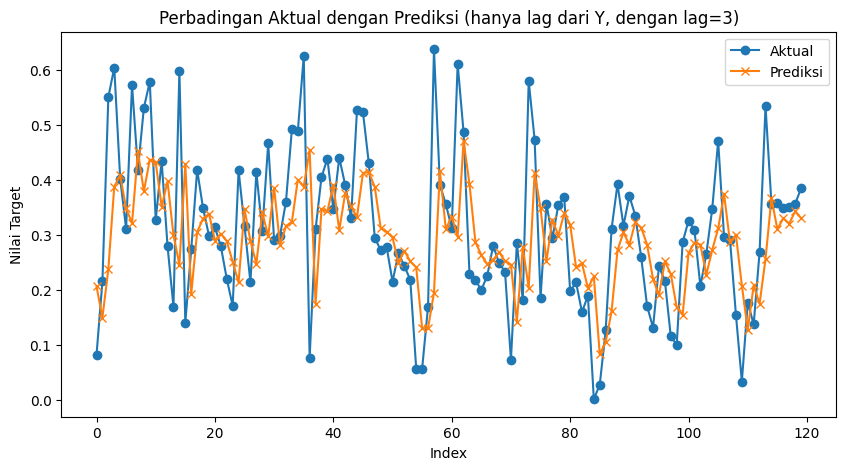

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

y_pred = final_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluasi Model:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test, label="Aktual", marker='o')
plt.plot(y_pred, label="Prediksi", marker='x')
plt.title("Perbadingan Aktual dengan Prediksi (hanya lag dari Y, dengan lag=3)")
plt.xlabel("Index")
plt.ylabel("Nilai Target")
plt.legend()
plt.show()

In [ ]:
import json

# --- Save best params to JSON ---
best_params = hof[0]
best_params_dict = {
    "units": float(best_params[0]),
    "dropout": float(best_params[1]),
    "learning_rate": float(best_params[2]),
    "epochs": float(best_params[3]),
    "batch_size": 32   # kalau batch size tetap
}

with open("best_params_PM25_1.json", "w") as f:
    json.dump(best_params_dict, f, indent=4)

print("Best params saved to best_params.json")

Best params saved to best_params.json


In [ ]:
# Simpan
final_model.save("final_model_PM25_1.keras")   # format HDF5